# Monte Carlo Analysis of Texas Hold'em

This project builds a Texas Hold'em simulator from first principles and uses Monte Carlo methods to investigate how outcomes change with table size and final hand strength.

The project then moves from descriptive analysis to a simplified decision experiment, comparing several participation policies in a four-player game. The aim is not to construct a complete poker solver, but to demonstrate hand evaluation, probabilistic simulation, conditional analysis, policy comparison and Monte Carlo convergence.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pathlib import Path

# Fixed seeds make the published simulation results reproducible.
SANITY_SEED = 39
PLAYER_COUNT_SEED = 40
HERO_SEED = 41
POLICY_SEED = 42

# Simulation sizes used for the final notebook results.
SANITY_NUM_SIMS = 100_000
PLAYER_COUNT_NUM_SIMS = 100_000
HERO_NUM_SIMS = 1_000_000
POLICY_NUM_SIMS = 1_000_000

FIGURE_DIRECTORY = Path("figures")
FIGURE_DIRECTORY.mkdir(exist_ok=True)

## 1. Card representation and dealing

Cards are represented by two-character strings. The first character gives the rank and the second gives the suit; for example, `Ah` represents the Ace of hearts and `Tc` represents the Ten of clubs.

A standard 52-card deck is created and shuffled before each game. Each player receives two private cards, followed by a five-card community board consisting of the flop, turn and river.

In [2]:
def create_deck():
    # Cards are represented by rank followed by suit:
    # "Ah" is the Ace of hearts, while "Tc" is the Ten of clubs.
    ranks = "23456789TJQKA"
    suits = "cdhs"

    deck = []

    for rank in ranks:
        for suit in suits:
            card = rank + suit
            deck.append(card)

    random.shuffle(deck)

    return deck

In [3]:
def deal_cards(deck, num_cards):
    if num_cards > len(deck):
        raise ValueError("Not enough cards remain in the deck")

    cards = deck[:num_cards]
    deck = deck[num_cards:]

    return cards, deck

In [4]:
def deal_game(num_players):
    if not 2 <= num_players <= 10:
        raise ValueError("num_players must be between 2 and 10")

    deck = create_deck()
    hands = []

    for i in range(num_players):
        hand, deck = deal_cards(deck, 2)
        hands.append(hand)

    flop, deck = deal_cards(deck, 3)
    turn, deck = deal_cards(deck, 1)
    river, deck = deal_cards(deck, 1)

    board = flop + turn + river

    return hands, flop, turn, river, board, deck

In [5]:
def show_game(num_players):
    hands, flop, turn, river, board, deck = deal_game(num_players)
    for i in range(num_players):
        print("Player",i+1,":", hands[i])
    print("Flop :", flop)
    print("Turn :", turn)
    print("River :",river)
    print("Board :",board)
    print("Cards remaining :", len(deck))

In [6]:
def get_rank_counts(cards):
    rank_counts = {}
    for card in cards:
        rank = card[0]
        if rank in rank_counts:
            rank_counts[rank] += 1
        else:
            rank_counts[rank] = 1
    return rank_counts

In [7]:
def get_suit_counts(cards):
    suit_counts = {}
    for card in cards:
        suit = card[1]
        if suit in suit_counts:
            suit_counts[suit] += 1
        else:
            suit_counts[suit] = 1
    return suit_counts

In [8]:
RANK_VALUES = {"2":2,"3":3,"4":4,"5":5,"6":6,"7":7,"8":8,"9":9,"T":10,"J":11,"Q":12,"K":13,"A":14}
def get_rank_value(rank):
    return RANK_VALUES[rank]

In [9]:
def get_flush_ranks(cards):
    suit_counts = get_suit_counts(cards)
    for suit in suit_counts:
        if suit_counts[suit]>=5:
            flush_ranks = []
            for card in cards:
                if card[1] == suit:
                    rank = card[0]
                    value = get_rank_value(rank)
                    flush_ranks.append(value)
            flush_ranks.sort(reverse=True)
            return flush_ranks[:5]
    return None

In [10]:
def group_ranks_by_count(cards):
    rank_counts = get_rank_counts(cards)
    single_ranks = []
    pair_ranks = []
    trip_ranks = []
    quad_ranks = []
    for rank in rank_counts:
        if rank_counts[rank] == 4:
            quad_ranks.append(get_rank_value(rank))
        elif rank_counts[rank] == 3:
            trip_ranks.append(get_rank_value(rank))
        elif rank_counts[rank] == 2:
            pair_ranks.append(get_rank_value(rank))
        else:
            single_ranks.append(get_rank_value(rank))
    single_ranks.sort(reverse=True)
    pair_ranks.sort(reverse=True)
    trip_ranks.sort(reverse=True)
    quad_ranks.sort(reverse=True)
    return single_ranks, pair_ranks, trip_ranks, quad_ranks

In [11]:
def get_unique_rank_values(cards):
    values = []
    for card in cards:
        rank = card[0]
        value = get_rank_value(rank)
        if value not in values:
            values.append(value)
    values.sort(reverse=True)
    return values

In [12]:
def get_straight_high_card(cards):
    values = get_unique_rank_values(cards)
    if 14 in values:
        values.append(1)
    streak = 1
    for i in range(len(values)-1):
        if values[i] - 1 == values[i+1]:
            streak += 1
            if streak == 5:
                return values[i-3]
        else:
            streak = 1
    return None

In [13]:
def get_straight_flush_high_card(cards):
    suit_counts = get_suit_counts(cards)

    for suit in suit_counts:
        if suit_counts[suit] >= 5:
            suited_cards = []

            for card in cards:
                if card[1] == suit:
                    suited_cards.append(card)

            straight_high = get_straight_high_card(suited_cards)

            if straight_high is not None:
                return straight_high

    return None

In [14]:
HAND_VALUES = {"high card": 0, "pair": 1, "two pair": 2, "three of a kind": 3, "straight": 4, "flush": 5, "full house": 6, "four of a kind": 7, "straight flush": 8}

## 2. Hand evaluation

Each player has seven available cards: two private cards and five community cards. The evaluator identifies the strongest five-card poker hand available from those seven cards.

A hand is represented by a score tuple. The first element gives the hand category, while subsequent elements contain the ranks required to break ties. Since Python compares tuples lexicographically, two complete poker hands can be compared directly.

For example, a pair is represented as:

`(pair category, pair rank, highest kicker, second kicker, third kicker)`

This means that pairs are first compared by the rank of the pair and then by their kickers.

In [15]:
# Hand scores are returned as tuples. Python compares tuples 
# lexicographically, so the category is compared first and
# the relevant ranks and kickers break ties afterward.
def evaluate_hand(cards):
    """
    Return a lexicographically comparable score for the
    strongest five-card hand available from seven cards.
    """
    single_ranks, pair_ranks, trip_ranks, quad_ranks = group_ranks_by_count(cards)

    straight_flush_high = get_straight_flush_high_card(cards)
    flush_ranks = get_flush_ranks(cards)
    straight_high = get_straight_high_card(cards)

    # Straight flush
    if straight_flush_high is not None:
        return (HAND_VALUES["straight flush"], straight_flush_high)

    # Four of a kind
    if len(quad_ranks) >= 1:
        kicker_candidates = trip_ranks + pair_ranks + single_ranks
        kicker_candidates.sort(reverse=True)

        return (HAND_VALUES["four of a kind"], quad_ranks[0], kicker_candidates[0])

    # Full house
    # If two trip ranks are present, the lower trip can provide
    # the pair component of the full house.
    full_house_pair_candidates = pair_ranks + trip_ranks[1:]
    full_house_pair_candidates.sort(reverse=True)

    if len(trip_ranks) >= 1 and len(full_house_pair_candidates) >= 1:
        return (HAND_VALUES["full house"], trip_ranks[0], full_house_pair_candidates[0])

    # Flush
    if flush_ranks is not None:
        return (HAND_VALUES["flush"],) + tuple(flush_ranks)

    # Straight
    if straight_high is not None:
        return (HAND_VALUES["straight"], straight_high)

    # Three of a kind
    if len(trip_ranks) >= 1:
        kicker_candidates = pair_ranks + single_ranks
        kicker_candidates.sort(reverse=True)

        return (HAND_VALUES["three of a kind"], trip_ranks[0], kicker_candidates[0], kicker_candidates[1])

    # Two pair
    if len(pair_ranks) >= 2:
        # With three available pairs, the third pair may be the
        # highest remaining kicker.
        kicker_candidates = pair_ranks[2:] + single_ranks
        kicker_candidates.sort(reverse=True)

        return (HAND_VALUES["two pair"], pair_ranks[0], pair_ranks[1], kicker_candidates[0])

    # Pair
    if len(pair_ranks) == 1:
        return (HAND_VALUES["pair"], pair_ranks[0], single_ranks[0], single_ranks[1], single_ranks[2])

    # High card
    return (HAND_VALUES["high card"], single_ranks[0], single_ranks[1], single_ranks[2], single_ranks[3], single_ranks[4])

In [16]:
def evaluate_players(hands, board):
    player_scores = []

    for i in range(len(hands)):
        cards = hands[i] + board
        score = evaluate_hand(cards)
        player_scores.append(score)

    return player_scores

In [17]:
def find_winners(hands, board):
    player_scores = evaluate_players(hands, board)

    best_score = max(player_scores)

    winners = []

    for i in range(len(player_scores)):
        if player_scores[i] == best_score:
            winners.append(i + 1)

    return winners, best_score

In [18]:
HAND_NAMES = {}

for hand_name in HAND_VALUES:
    hand_value = HAND_VALUES[hand_name]
    HAND_NAMES[hand_value] = hand_name

### Evaluator validation

The evaluator is tested on several important edge cases, including an Ace-low straight, two sets of trips forming a full house, three available pairs, flush kickers, quads with different kickers and a hand tied entirely by the community board.

In [19]:
def run_core_validation_tests():
    # Deck construction
    deck = create_deck()

    assert len(deck) == 52
    assert len(set(deck)) == 52

    # Four-player deal: 8 private cards, 5 board cards,
    # and 39 cards remaining.
    hands, flop, turn, river, board, remaining_deck = deal_game(4)

    dealt_cards = [
        card
        for hand in hands
        for card in hand
    ] + board

    assert len(hands) == 4
    assert all(len(hand) == 2 for hand in hands)
    assert len(flop) == 3
    assert len(turn) == 1
    assert len(river) == 1
    assert len(board) == 5
    assert len(remaining_deck) == 39
    assert len(dealt_cards) == len(set(dealt_cards))

    # Ace-low straight
    assert evaluate_hand(
        ["Ah", "2c", "3d", "4s", "5h", "9c", "Kd"]
    ) == (
        HAND_VALUES["straight"],
        5
    )

    # Straight flush
    assert evaluate_hand(
        ["Ah", "Kh", "Qh", "Jh", "Th", "2c", "3d"]
    ) == (
        HAND_VALUES["straight flush"],
        14
    )

    # Two sets of trips form a full house
    assert evaluate_hand(
        ["Ah", "Ac", "Ad", "Kh", "Kc", "Kd", "2s"]
    ) == (
        HAND_VALUES["full house"],
        14,
        13
    )

    # With three pairs, select the best two and use
    # the remaining pair rank as the kicker.
    assert evaluate_hand(
        ["Ah", "Ac", "Kh", "Kc", "Qh", "Qc", "2s"]
    ) == (
        HAND_VALUES["two pair"],
        14,
        13,
        12
    )

    # Flush comparison uses five ranks
    assert evaluate_hand(
        ["Ah", "Jh", "9h", "6h", "2h", "Kc", "Qd"]
    ) == (
        HAND_VALUES["flush"],
        14,
        11,
        9,
        6,
        2
    )

    # Shared royal flush on the board produces a tie
    tied_hands = [
        ["2c", "3d"],
        ["4c", "5d"]
    ]

    tied_board = [
        "Ah", "Kh", "Qh", "Jh", "Th"
    ]

    winners, winning_score = find_winners(
        tied_hands,
        tied_board
    )

    assert winners == [1, 2]
    assert winning_score == (
        HAND_VALUES["straight flush"],
        14
    )

    # Quads are separated by the kicker
    quad_hands = [
        ["Kh", "Qd"],
        ["Jh", "Td"]
    ]

    quad_board = [
        "Ah", "Ac", "Ad", "As", "2c"
    ]

    winners, _ = find_winners(
        quad_hands,
        quad_board
    )

    assert winners == [1]

    # Invalid table sizes are rejected.
    try:
        deal_game(1)
    except ValueError:
        pass
    else:
        raise AssertionError(
            "deal_game should reject fewer than two players"
        )

    try:
        deal_game(11)
    except ValueError:
        pass
    else:
        raise AssertionError(
            "deal_game should reject more than ten players"
        )

    # A deal cannot request more cards than remain.
    try:
        deal_cards(["Ah"], 2)
    except ValueError:
        pass
    else:
        raise AssertionError(
            "deal_cards should reject an oversized request"
        )

    print("All core validation tests passed.")


run_core_validation_tests()

All core validation tests passed.


In [20]:
def show_winners(hands, board):
    winners, best_score = find_winners(hands, board)

    hand_type_value = best_score[0]
    hand_type_name = HAND_NAMES[hand_type_value]

    print("Board:", board)
    print()

    for i in range(len(hands)):
        player_cards = hands[i] + board
        player_score = evaluate_hand(player_cards)

        print("Player", i + 1)
        print("Hand:", hands[i])
        print("Best score:", player_score)
        print("Best hand type:", HAND_NAMES[player_score[0]])
        print()

    if len(winners) == 1:
        print("Winner: Player", winners[0])
    else:
        print("Pot split between players:", winners)

    print("Winning hand:", hand_type_name)
    print("Winning score:", best_score)

## 3. Monte Carlo simulation

Monte Carlo simulation estimates quantities by repeatedly generating random games and recording their outcomes.

When a pot is split, each winner receives fractional equity. For example, a player in a two-way tie receives one half of a win. This ensures that the total equity assigned in each game is exactly one.

In [21]:
def simulate_one_game(num_players):
    hands, flop, turn, river, board, deck = deal_game(num_players)
    winners, best_score = find_winners(hands, board)

    return hands, board, winners, best_score

In [22]:
def simulate_many_games(num_players, num_sims):
    """
    Simulate complete random Hold'em deals and return player
    equity, tie counts and winning-hand frequencies.
    """
    win_count = {}
    tie_count = 0
    winning_hand_count = {}

    for player in range(1, num_players + 1):
        win_count[player] = 0

    for hand_name in HAND_VALUES:
        winning_hand_count[hand_name] = 0

    for i in range(num_sims):
        hands, board, winners, best_score = simulate_one_game(num_players)

        if len(winners) > 1:
            tie_count += 1

        # Split pots contribute fractional equity, ensuring that
        # total player equity in every game sums to one.

        win_share = 1 / len(winners)

        for winner in winners:
            win_count[winner] += win_share

        winning_hand_value = best_score[0]
        winning_hand_name = HAND_NAMES[winning_hand_value]
        winning_hand_count[winning_hand_name] += 1

    return win_count, tie_count, winning_hand_count

### Simulation sanity check

Because every seat is dealt symmetrically, the players should have approximately equal equity over a large number of random games. Total player equity should also sum to one.

In [23]:
random.seed(SANITY_SEED)

win_count, tie_count, winning_hand_count = simulate_many_games(
    num_players=3,
    num_sims=SANITY_NUM_SIMS
)

for player in win_count:
    win_rate = win_count[player] / SANITY_NUM_SIMS
    print("Player", player, "equity:", f"{win_rate:.2%}")

print("Tie rate:", f"{tie_count / SANITY_NUM_SIMS:.2%}")
print(
    "Total equity:",
    sum(win_count.values()) / SANITY_NUM_SIMS
)

assert abs(
    sum(win_count.values()) / SANITY_NUM_SIMS - 1
) < 1e-10

Player 1 equity: 33.45%
Player 2 equity: 33.26%
Player 3 equity: 33.29%
Tie rate: 4.65%
Total equity: 0.9999999999999887


## 4. Effect of the number of players

The first experiment varies the number of players from 2 to 10. It measures the frequency of ties and the distribution of selected winning hand categories.

This tests the intuition that, as more opponents are added, the strongest hand among all players is likely to become stronger.

In [24]:
def analyse_by_player_count(num_sims):
    tie_rates = {}
    hand_type_results = {}

    for num_players in range(2, 11):
        win_count, tie_count, winning_hand_count = simulate_many_games(num_players, num_sims)

        tie_rates[num_players] = tie_count / num_sims * 100

        frequencies = {}

        for hand_name in winning_hand_count:
            frequency = winning_hand_count[hand_name] / num_sims * 100
            frequencies[hand_name] = frequency

        hand_type_results[num_players] = frequencies

    return tie_rates, hand_type_results

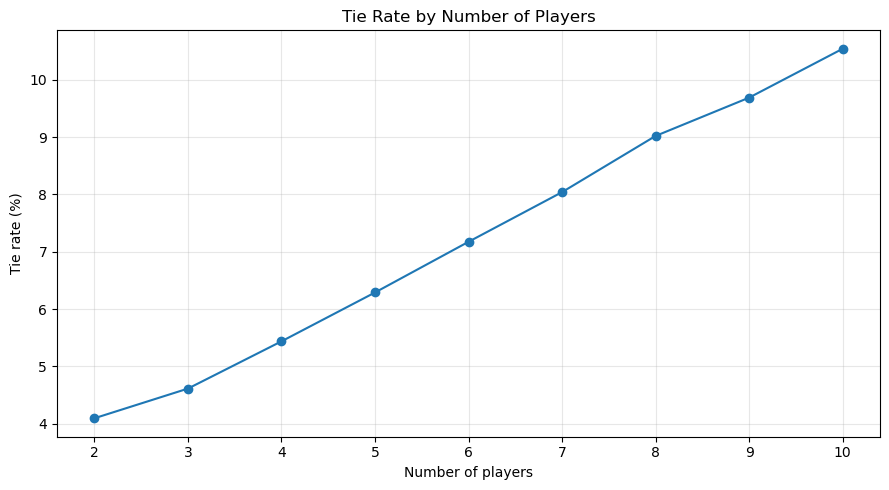

In [25]:
random.seed(PLAYER_COUNT_SEED)

tie_rates, hand_type_results = analyse_by_player_count(
    PLAYER_COUNT_NUM_SIMS
)
x = list(tie_rates.keys())
y = list(tie_rates.values())

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, y, marker="o")

ax.set_xlabel("Number of players")
ax.set_ylabel("Tie rate (%)")
ax.set_title("Tie Rate by Number of Players")
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "tie_rate_by_player_count.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

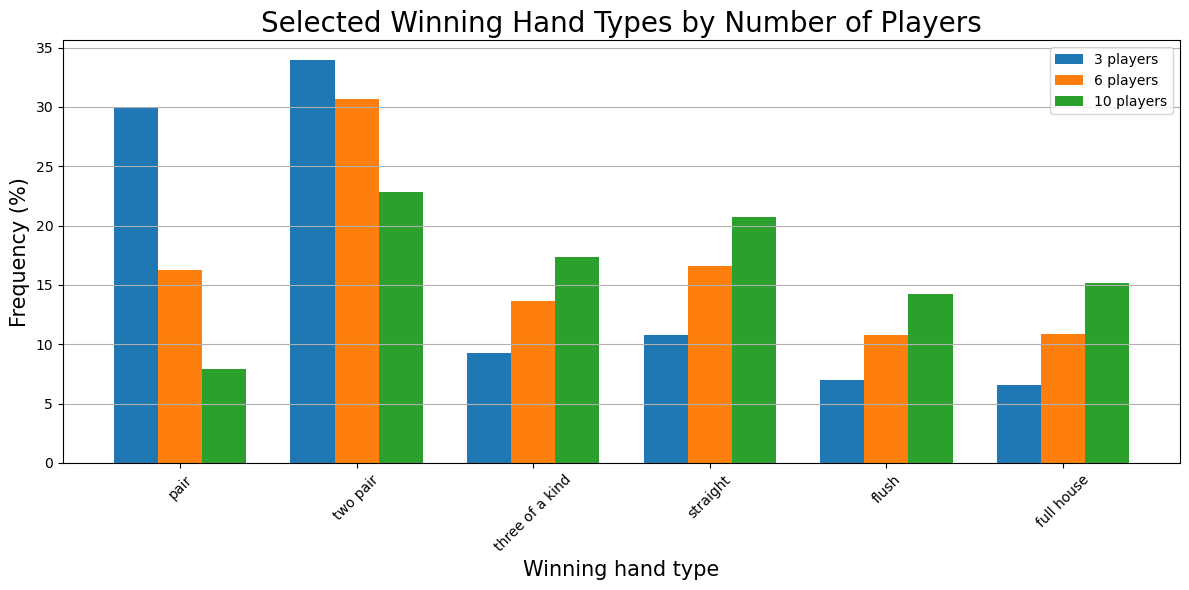

In [26]:
selected_players = [3, 6, 10]

hand_types = ["pair", "two pair", "three of a kind", "straight", "flush", "full house"]

x = np.arange(len(hand_types))
bar_width = 0.25

plt.figure(figsize=(12, 6))

for i in range(len(selected_players)):
    num_players = selected_players[i]

    frequencies = []

    for hand_name in hand_types:
        frequencies.append(hand_type_results[num_players][hand_name])

    plt.bar(x + i * bar_width, frequencies, width=bar_width, label=str(num_players) + " players")

plt.xlabel("Winning hand type",fontsize=15)
plt.ylabel("Frequency (%)",fontsize=15)
plt.title("Selected Winning Hand Types by Number of Players",fontsize=20)
plt.xticks(x + bar_width, hand_types, rotation=45)
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(
    FIGURE_DIRECTORY / "selected_winning_hands.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

As the number of players increases, the winning hand distribution shifts toward stronger categories. This reflects an order-statistics effect: with more independently dealt opponents, the strongest hand present at the table is likely to improve.

The figure shows selected common categories only. High-card wins and the rarest categories are omitted to keep the comparison readable.

## 5. Conditional outcomes for a four-player Hero

The analysis now fixes the table size at four players and treats Player 1 as Hero.

For each final Hero hand category, the simulation records outright wins, split pots, losses and total equity. Equity is the most complete measure because it awards one unit for an outright win, zero for a loss and the appropriate fractional share for a tie.

In [27]:
def analyse_hero_hand_types(num_players,num_sims):
    """
    Estimate Hero's conditional outcomes and equity for each
    final hand category.
    """
    # Player 1 is treated as Hero throughout the analysis.
    hero_results = {}

    for hand_name in HAND_VALUES:
        hero_results[hand_name] = {"count": 0, "wins": 0, "ties": 0, "losses": 0, "equity_sum": 0}

    for i in range(num_sims):
        hands, board, winners, best_score = simulate_one_game(num_players)
        hero_hand_name = HAND_NAMES[evaluate_hand(hands[0]+board)[0]]
        hero_results[hero_hand_name]["count"] += 1
        if 1 in winners and len(winners) == 1:
            hero_results[hero_hand_name]["wins"] += 1
            hero_results[hero_hand_name]["equity_sum"] += 1
        elif 1 in winners and len(winners) > 1:
            hero_results[hero_hand_name]["ties"] += 1
            hero_results[hero_hand_name]["equity_sum"] += 1/len(winners)
        else:
            hero_results[hero_hand_name]["losses"] += 1

    for hand_name in hero_results:
        results = hero_results[hand_name]
        count = results["count"]

        assert (
            results["wins"]
            + results["ties"]
            + results["losses"]
            == count
        )

        if count > 0:
            results["win_rate"] = results["wins"] / count
            results["tie_rate"] = results["ties"] / count
            results["loss_rate"] = results["losses"] / count
            results["equity"] = results["equity_sum"] / count

            assert abs(
                results["win_rate"]
                + results["tie_rate"]
                + results["loss_rate"]
                - 1
            ) < 1e-10

        else:
            results["win_rate"] = None
            results["tie_rate"] = None
            results["loss_rate"] = None
            results["equity"] = None

    return hero_results

In [28]:
random.seed(HERO_SEED)

hero_results = analyse_hero_hand_types(
    num_players=4,
    num_sims=HERO_NUM_SIMS
)

In [29]:
def create_hero_summary(hero_results, num_sims):
    rows = []

    for hand_name in HAND_VALUES:
        results = hero_results[hand_name]
        row = {"Hand type": hand_name.title(),"Count": results["count"],"Frequency": results["count"] / num_sims,"Win rate": results["win_rate"],"Tie rate": results["tie_rate"],"Loss rate": results["loss_rate"],"Equity": results["equity"]}
        rows.append(row)

    summary = pd.DataFrame(rows)

    return summary

In [30]:
hero_summary = create_hero_summary(
    hero_results,
    HERO_NUM_SIMS
)
display(hero_summary.style.format({"Frequency": "{:.2%}","Win rate": "{:.2%}","Tie rate": "{:.2%}","Loss rate": "{:.2%}","Equity": "{:.2%}"}, na_rep="-"))
assert hero_summary["Count"].sum() == HERO_NUM_SIMS

,Hand type,Count,Frequency,Win rate,Tie rate,Loss rate,Equity
0,High Card,174114,17.41%,0.77%,0.22%,99.01%,0.87%
1,Pair,438449,43.84%,13.18%,1.26%,85.55%,13.79%
2,Two Pair,234857,23.49%,33.97%,4.52%,61.52%,36.05%
3,Three Of A Kind,48205,4.82%,55.81%,2.82%,41.37%,57.14%
4,Straight,46194,4.62%,62.39%,19.46%,18.15%,70.88%
5,Flush,30265,3.03%,69.88%,1.93%,28.19%,70.36%
6,Full House,25942,2.59%,73.98%,10.31%,15.72%,78.25%
7,Four Of A Kind,1675,0.17%,87.52%,3.88%,8.60%,88.81%
8,Straight Flush,299,0.03%,93.98%,4.35%,1.67%,95.07%


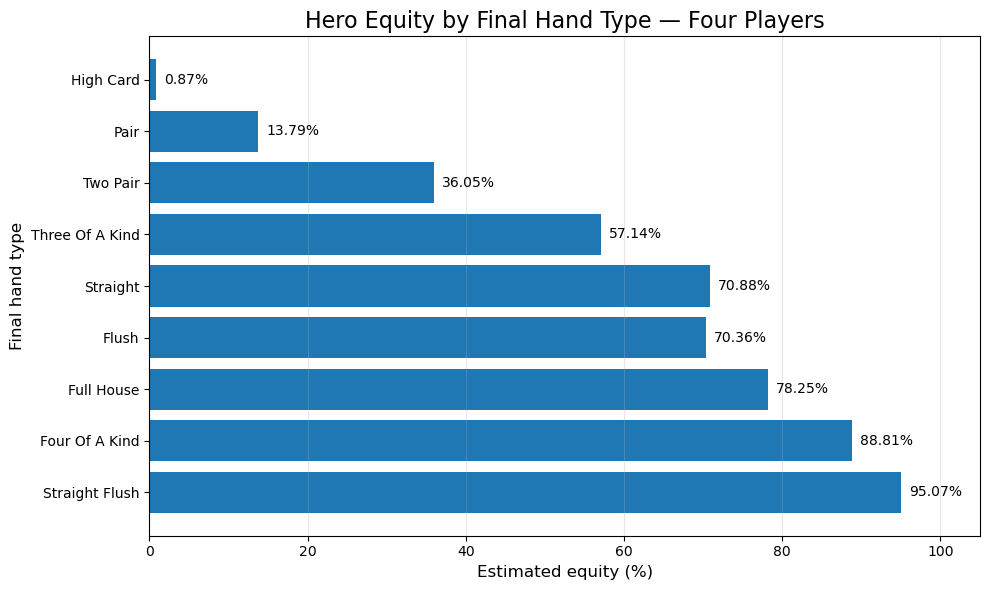

In [31]:
# Convert equity from decimals to percentages
equity_percent = hero_summary["Equity"] * 100

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(hero_summary["Hand type"],equity_percent)

# Put High Card at the top and Straight Flush at the bottom
ax.invert_yaxis()

ax.set_xlabel("Estimated equity (%)", fontsize=12)
ax.set_ylabel("Final hand type", fontsize=12)
ax.set_title("Hero Equity by Final Hand Type — Four Players",fontsize=16)

ax.set_xlim(0, 105)
ax.grid(axis="x", alpha=0.3)

# Add percentage labels beside each bar
for bar, equity in zip(bars, equity_percent):
    ax.text(equity + 1,bar.get_y() + bar.get_height() / 2,f"{equity:.2f}%",va="center")

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "hero_equity_by_hand_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

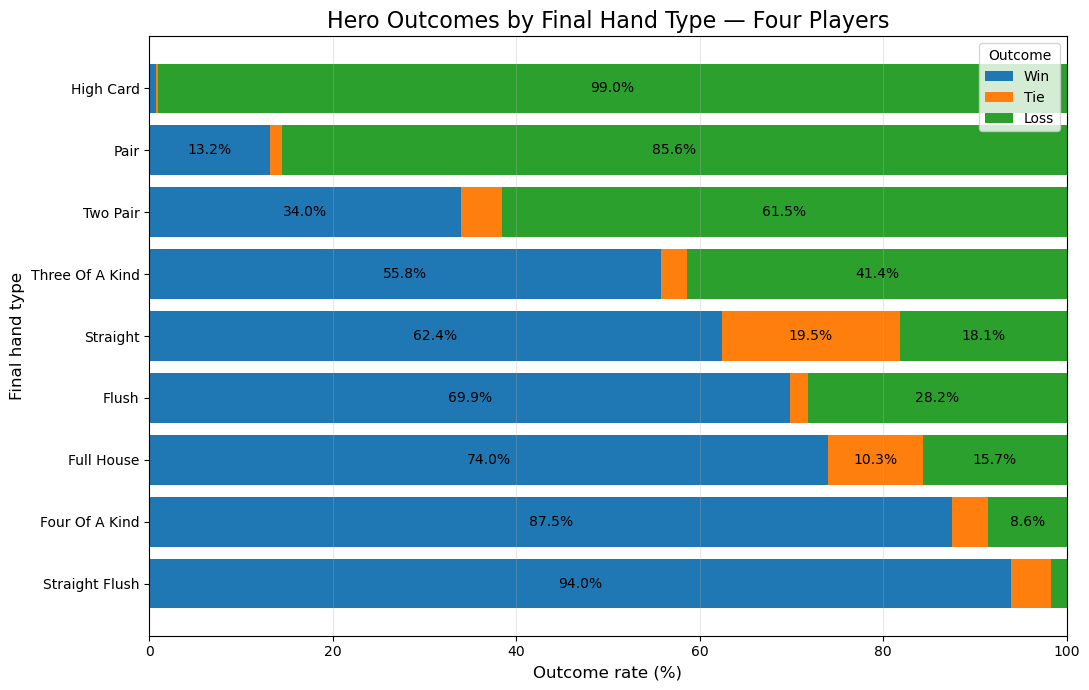

In [32]:
hand_types = hero_summary["Hand type"]

win_percent = hero_summary["Win rate"] * 100
tie_percent = hero_summary["Tie rate"] * 100
loss_percent = hero_summary["Loss rate"] * 100

fig, ax = plt.subplots(figsize=(11, 7))

# First section: wins
ax.barh(hand_types,win_percent,label="Win")

# Second section: ties, beginning where wins end
ax.barh(hand_types,tie_percent,left=win_percent,label="Tie")

# Third section: losses, beginning where wins and ties end
ax.barh(hand_types,loss_percent,left=win_percent + tie_percent,label="Loss")

# Keep hand categories in natural poker-strength order
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_xlabel("Outcome rate (%)", fontsize=12)
ax.set_ylabel("Final hand type", fontsize=12)
ax.set_title("Hero Outcomes by Final Hand Type — Four Players",fontsize=16)

ax.legend(title="Outcome")
ax.grid(axis="x", alpha=0.3)

# Add labels to sections large enough to display clearly
for i in range(len(hero_summary)):
    values = [win_percent.iloc[i],tie_percent.iloc[i],loss_percent.iloc[i]]

    starting_position = 0

    for value in values:
        if value >= 5:
            ax.text(starting_position + value / 2,i,f"{value:.1f}%",ha="center",va="center")
        starting_position += value

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "hero_outcomes_by_hand_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The results show the substantial difference between merely completing a hand category and holding a hand that is strong relative to three opponents.

The estimates for rare categories should be interpreted with more caution because they are based on fewer observations. The accompanying table therefore reports both estimated equity and the number of simulated occurrences.

## 6. Simplified participation-policy experiment

The final experiment moves from analysing outcomes to comparing decision rules.

Each policy decides whether Hero should participate using only Hero's final hand category. All policies are evaluated on exactly the same simulated games, so differences between their estimated returns are driven by their decisions rather than by different random samples.

### Policy-model assumptions

- The game contains four players.
- Hero observes their final seven-card hand after the complete board is known.
- Hero does not observe opponents' private cards.
- Participating costs one unit.
- If Hero participates, the model assumes a pot containing one unit from each player.
- Folding produces zero incremental profit.
- An outright winner receives the full pot and tied winners divide it equally.
- Blinds, earlier betting, variable bet sizes, opponent folds, bluffing, ranges, rake and strategic responses are excluded.

If Hero is one of \(k\) winners in an \(N\)-player game, the net profit is

$$
\frac{N}{k} - 1
$$

If Hero loses, the net profit is \(-1\).

In [33]:
def always_participate(hero_score):
    return True

def pair_or_better(hero_score):
    return hero_score[0] >= HAND_VALUES["pair"]

def two_pair_or_better(hero_score):
    return hero_score[0] >= HAND_VALUES["two pair"]

def three_of_a_kind_or_better(hero_score):
    return hero_score[0] >= HAND_VALUES["three of a kind"]

def straight_or_better(hero_score):
    return hero_score[0] >= HAND_VALUES["straight"]

In [34]:
def calculate_participation_profit(winners, num_players):
    """
    Calculate Hero's profit conditional on participating.

    Hero contributes one unit.

    If Hero loses, the contribution is lost.

    If Hero wins or ties, Hero receives an equal share
    of a pot containing one unit from each player.
    """

    if 1 not in winners:
        return -1

    return num_players / len(winners) - 1

In [35]:
policies = {"Always participate": always_participate,"Pair or better": pair_or_better,"Two pair or better": two_pair_or_better,"Three of a kind or better": three_of_a_kind_or_better,"Straight or better": straight_or_better}

In [36]:
def simulate_policies(policies,num_sims,num_players=4,record_every=1000,seed=None):
    """
    Compare participation policies on a shared sequence of
    simulated four-player games.
    """
    # Every policy is evaluated on the same simulated deal.
    # This reduces noise when comparing the policies.
    if seed is not None:
        random.seed(seed)

    policy_results = {}

    for policy_name in policies:
        policy_results[policy_name] = {"participation_count": 0,"wins": 0,"ties": 0,"losses": 0,"total_profit": 0,"running_profit_per_game": []}

    # Store estimates only at regular checkpoints rather than
    # saving one value for every simulated game.
    
    checkpoints = []

    for sim_number in range(1, num_sims + 1):
        hands, board, winners, _ = simulate_one_game(num_players)

        hero_score = evaluate_hand(hands[0] + board)

        for policy_name, policy_function in policies.items():
            participates = policy_function(hero_score)

            if not participates:
                continue

            results = policy_results[policy_name]

            results["participation_count"] += 1

            profit = calculate_participation_profit(winners,num_players)

            results["total_profit"] += profit

            if 1 not in winners:
                results["losses"] += 1

            elif len(winners) == 1:
                results["wins"] += 1

            else:
                results["ties"] += 1

        # Save running estimates at chosen intervals
        if (sim_number % record_every == 0) or (sim_number == num_sims):
            checkpoints.append(sim_number)

            for policy_name in policies:
                running_average = policy_results[policy_name]["total_profit"] / sim_number

                policy_results[policy_name]["running_profit_per_game"].append(running_average)

    # Calculate final summary statistics
    for policy_name in policies:
        results = policy_results[policy_name]

        participation_count = results["participation_count"]

        assert (results["wins"] + results["ties"] + results["losses"] == participation_count)

        results["participation_rate"] = participation_count / num_sims

        results["profit_per_game"] = results["total_profit"] / num_sims

        if participation_count > 0:
            results["profit_per_participation"] = results["total_profit"] / participation_count
                
            results["win_rate_when_participating"] = results["wins"] / participation_count

            results["tie_rate_when_participating"] = results["ties"] / participation_count

            results["loss_rate_when_participating"] = results["losses"] / participation_count

        else:
            results["profit_per_participation"] = None
            results["win_rate_when_participating"] = None
            results["tie_rate_when_participating"] = None
            results["loss_rate_when_participating"] = None

    return policy_results, checkpoints

In [37]:
def run_policy_validation_tests():
    high_card_score = (
        HAND_VALUES["high card"],
        14,
        13,
        12,
        11,
        9
    )

    pair_score = (
        HAND_VALUES["pair"],
        10,
        14,
        12,
        9
    )

    two_pair_score = (
        HAND_VALUES["two pair"],
        10,
        8,
        14
    )

    trips_score = (
        HAND_VALUES["three of a kind"],
        7,
        14,
        12
    )

    straight_score = (
        HAND_VALUES["straight"],
        10
    )

    assert always_participate(high_card_score)

    assert not pair_or_better(high_card_score)
    assert pair_or_better(pair_score)

    assert not two_pair_or_better(pair_score)
    assert two_pair_or_better(two_pair_score)

    assert not three_of_a_kind_or_better(two_pair_score)
    assert three_of_a_kind_or_better(trips_score)

    assert not straight_or_better(trips_score)
    assert straight_or_better(straight_score)

    # Four-player payoff checks
    assert calculate_participation_profit([1], 4) == 3
    assert calculate_participation_profit([1, 2], 4) == 1

    assert abs(
        calculate_participation_profit(
            [1, 2, 3],
            4
        ) - 1 / 3
    ) < 1e-10

    assert calculate_participation_profit(
        [1, 2, 3, 4],
        4
    ) == 0

    assert calculate_participation_profit([2], 4) == -1

    print("All policy validation tests passed.")


run_policy_validation_tests()

All policy validation tests passed.


In [38]:
policy_results, checkpoints = simulate_policies(
    policies=policies,
    num_sims=POLICY_NUM_SIMS,
    num_players=4,
    record_every=1_000,
    seed=POLICY_SEED
)

In [39]:
def create_policy_summary(policy_results):
    rows = []

    for policy_name in policy_results:
        results = policy_results[policy_name]

        rows.append({"Policy": policy_name,"Participations": results["participation_count"],"Participation rate": results["participation_rate"],"Wins": results["wins"],"Ties": results["ties"],"Losses": results["losses"],"Total profit": results["total_profit"],"Profit per game": results["profit_per_game"],"Profit per participation": (results["profit_per_participation"]),"Win rate when participating": (results["win_rate_when_participating"]),"Tie rate when participating": (results["tie_rate_when_participating"]),"Loss rate when participating": (results["loss_rate_when_participating"])})
    return pd.DataFrame(rows)


policy_summary = create_policy_summary(policy_results)
display(policy_summary.style.format({"Participation rate": "{:.2%}","Total profit": "{:.2f}","Profit per game": "{:.4f}","Profit per participation": "{:.4f}","Win rate when participating": "{:.2%}","Tie rate when participating": "{:.2%}","Loss rate when participating": "{:.2%}"}))

,Policy,Participations,Participation rate,Wins,Ties,Losses,Total profit,Profit per game,Profit per participation,Win rate when participating,Tie rate when participating,Loss rate when participating
0,Always participate,1000000,100.00%,235946,30003,734051,-2283.00,-0.0023,-0.0023,23.59%,3.00%,73.41%
1,Pair or better,825840,82.58%,234560,29609,561671,165587.00,0.1656,0.2005,28.40%,3.59%,68.01%
2,Two pair or better,387383,38.74%,176869,24243,186271,363018.67,0.3630,0.9371,45.66%,6.26%,48.08%
3,Three of a kind or better,152882,15.29%,97760,13744,41378,261705.67,0.2617,1.7118,63.94%,8.99%,27.07%
4,Straight or better,104382,10.44%,70685,12330,21367,199226.67,0.1992,1.9086,67.72%,11.81%,20.47%


### Interpreting the policy metrics

**Profit per game** is the main measure used to compare policies. It divides total profit by every simulated deal, including games in which Hero folds.

**Profit per participation** measures the average return conditional on the policy choosing to act. A highly selective policy may perform very well when participating while still rejecting many potentially profitable opportunities.

The comparison therefore illustrates a trade-off between selectivity, participation frequency and overall expected return.

### Monte Carlo convergence

A running estimate of profit per simulated game is recorded at regular checkpoints.

If the simulation is behaving well, each line should become increasingly stable as the sample size grows. The always-participate policy provides a useful benchmark: because all players are dealt symmetrically, its expected profit should converge toward zero under the simplified payoff model.

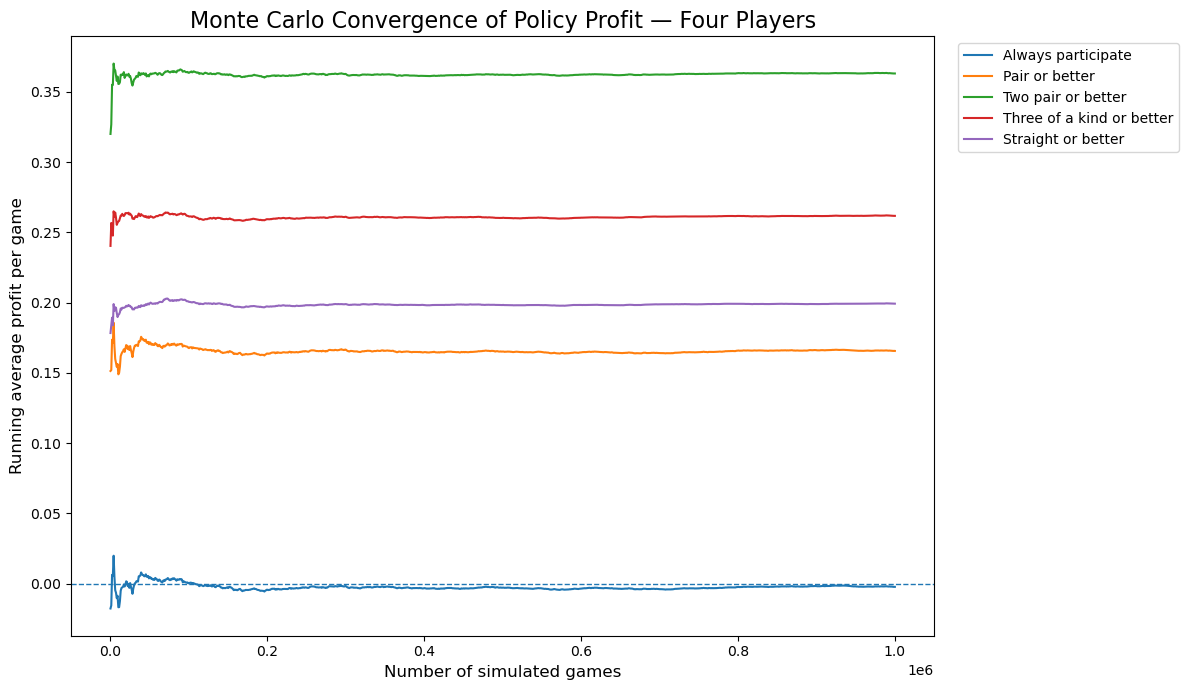

In [40]:
fig, ax = plt.subplots(figsize=(12, 7))

for policy_name in policies:
    ax.plot(checkpoints,policy_results[policy_name]["running_profit_per_game"],label=policy_name)

ax.axhline(0,linestyle="--",linewidth=1)

ax.set_xlabel("Number of simulated games",fontsize=12)

ax.set_ylabel("Running average profit per game",fontsize=12)

ax.set_title("Monte Carlo Convergence of Policy Profit — Four Players",fontsize=16)

ax.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "policy_convergence.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

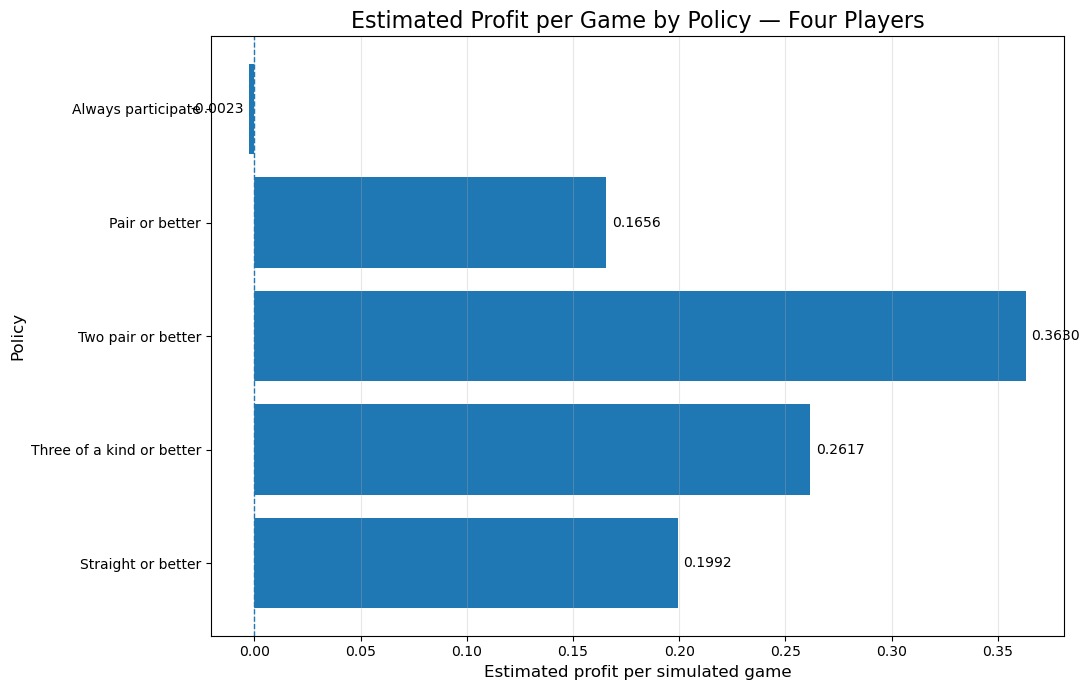

In [41]:
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(policy_summary["Policy"],policy_summary["Profit per game"])

ax.invert_yaxis()

ax.axvline(0,linestyle="--",linewidth=1)

ax.set_xlabel("Estimated profit per simulated game",fontsize=12)

ax.set_ylabel("Policy",fontsize=12)

ax.set_title("Estimated Profit per Game by Policy — Four Players",fontsize=16)

ax.grid(axis="x", alpha=0.3)

ax.bar_label(bars,fmt="%.4f",padding=4)

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "policy_profit_per_game.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

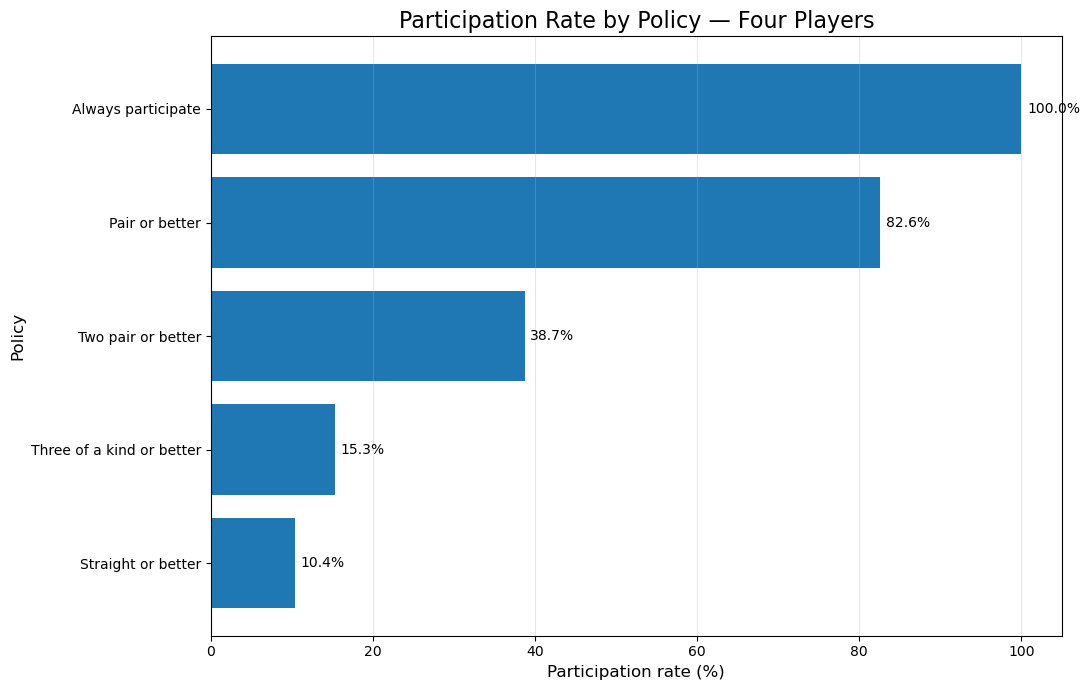

In [42]:
participation_percent = policy_summary["Participation rate"] * 100

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(policy_summary["Policy"],participation_percent)

ax.invert_yaxis()
ax.set_xlim(0, 105)

ax.set_xlabel("Participation rate (%)",fontsize=12)

ax.set_ylabel("Policy",fontsize=12)

ax.set_title("Participation Rate by Policy — Four Players",fontsize=16)

ax.grid(axis="x", alpha=0.3)

ax.bar_label(bars,labels=[f"{value:.1f}%" for value in participation_percent],padding=4)

plt.tight_layout()
fig.savefig(
    FIGURE_DIRECTORY / "policy_participation_rate.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [43]:
assert (
    policy_results["Always participate"]["participation_count"]
    == POLICY_NUM_SIMS
)

participation_counts = [
    policy_results[policy_name]["participation_count"]
    for policy_name in policies
]

assert all(
    participation_counts[i] >= participation_counts[i + 1]
    for i in range(len(participation_counts) - 1)
)

for policy_name, results in policy_results.items():
    assert (
        results["wins"]
        + results["ties"]
        + results["losses"]
        == results["participation_count"]
    )

always_profit = policy_results[
    "Always participate"
]["profit_per_game"]

print(
    "Always-participate profit per game:",
    always_profit
)

Always-participate profit per game: -0.0022829999999999903


## 7. Main findings

- Increasing the number of players shifts winning outcomes toward stronger hand categories.
- Final hand category strongly affects Hero's conditional equity in a four-player game.
- More selective policies generally achieved higher profit per participation, but acted less frequently.
- Among the tested policies, **two pair or better** produced the highest estimated profit per game at **0.3630** units per deal.
- The always-participate policy converged close to zero, providing a useful validation of the symmetric payoff model.
- The convergence plot demonstrates that the Monte Carlo estimates become progressively more stable as the number of simulated games increases.

## 8. Limitations and possible extensions

The policy experiment is a stylised decision model rather than a complete poker strategy.

The policies use only broad final hand categories and ignore how Hero's private cards interact with the board. They also exclude pot odds, previous contributions, betting sequences, opponent ranges, folds, bluffing, position, variable bet sizes and strategic adaptation.

Possible extensions include policies based on the complete hand-score tuple, board texture or estimated opponent ranges. These are left outside the current project in order to preserve a focused and interpretable model.